In [ ]:
# JPY Bond PV & Risk Attribution

段階的に JPY 固定利付債の **Pricing → Risk Measures → PnL Attribution** を実装するノートブック。

## ロードマップ
1. ~~データ構造 & 入力定義~~ ✔
2. ~~Date / Schedule ユーティリティ~~ ✔
3. ~~OIS Curve クラス~~ ✔
4. ~~Fixed Bond Pricing (Risk-Free)~~ ✔
5. ~~OIS Key-Rate Delta / Gamma (Fixed)~~ ✔
6. ~~Floating Rate Note (FRN) Pricing~~ ✔
7. ~~OIS Key-Rate Delta / Gamma (FRN) & Fixed vs FRN 比較~~ ✔
8. **Fixed Bond + Z-Spread Pricing & Risk** ← 今ここ
9. PnL Attribution (Carry / Roll-down / Rate Change / Residual)

## 1. Imports

In [53]:
from __future__ import annotations

import datetime as dt
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import QuantLib as ql

# TODO: ql.Settings.instance().evaluationDate の設定を MarketSnapshot から行う

## 2. データ構造定義

債券スペック・マーケットデータ・リスク設定を `dataclass` で定義する。

In [54]:
@dataclass
class BondSpec:
    """JPY 固定利付債のスペック."""
    name: str                          # 銘柄名 / 識別子
    coupon_rate: float                  # 年率クーポン (例: 0.005 = 0.5%)
    issue_date: dt.date                # 発行日
    maturity_date: dt.date             # 償還日
    face_value: float = 100_000_000    # 額面 (円)
    coupon_frequency: int = 2          # 利払い回数/年 (半年毎=2)
    day_count: str = "ActualActual"    # 日数計算規約
    calendar: str = "Japan"            # 営業日カレンダー
    settlement_days: int = 2           # 受渡日までの営業日数

    # TODO: 物価連動債への拡張
    # TODO: 償還スケジュール (amortizing) 対応


@dataclass
class FloatingBondSpec:
    """JPY 変動利付債 (TONA/OIS ベース FRN) のスペック."""
    name: str                          # 銘柄名 / 識別子
    spread: float                      # スプレッド over reference rate (年率, 例: 0.001 = 10bp)
    issue_date: dt.date                # 発行日
    maturity_date: dt.date             # 償還日
    face_value: float = 100_000_000    # 額面 (円)
    coupon_frequency: int = 4          # 利払い回数/年 (四半期毎=4)
    day_count: str = "Actual365Fixed"  # 日数計算規約 (TONA FRN は Act/365Fixed が一般的)
    calendar: str = "Japan"            # 営業日カレンダー
    settlement_days: int = 2           # 受渡日までの営業日数
    fixing_lag: int = 0                # fixing のラグ (営業日数, TONA は通常 0)


@dataclass
class MarketSnapshot:
    """ある時点のマーケットデータ."""
    eval_date: dt.date                                # 評価日
    ois_tenors: list[str] = field(default_factory=list)   # テナーラベル ("1Y", "5Y", …)
    ois_rates: list[float] = field(default_factory=list)  # OIS レート (連続複利 or 単利は後で統一)

    # TODO: JGB par yield カーブ追加
    # TODO: Z-spread / ASW スプレッド入力
    # TODO: repo rate


@dataclass
class RiskConfig:
    """リスク計算の設定."""
    bump_size_bps: float = 1.0         # パラレルバンプ幅 (bp)
    key_rate_tenors: list[str] = field(
        default_factory=lambda: ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y", "40Y"]
    )
    use_ois_discounting: bool = True   # OIS ディスカウント使用フラグ

    # TODO: CS01 / スプレッドリスク設定
    # TODO: シナリオ分析用パラメータ

## 3. ユーティリティ関数

QuantLib オブジェクトへの変換ヘルパー。

In [55]:
# ── date 変換 ─────────────────────────────────────────


def to_ql_date(d: dt.date) -> ql.Date:
    """Python date → QuantLib Date."""
    return ql.Date(d.day, d.month, d.year)


def to_py_date(d: ql.Date) -> dt.date:
    """QuantLib Date → Python date."""
    return dt.date(d.year(), d.month(), d.dayOfMonth())


# ── lookup maps ───────────────────────────────────────

DAY_COUNT_MAP: dict[str, ql.DayCounter] = {
    "ActualActual": ql.ActualActual(ql.ActualActual.ISDA),
    "Actual365Fixed": ql.Actual365Fixed(),
    "Thirty360": ql.Thirty360(ql.Thirty360.BondBasis),
}

CALENDAR_MAP: dict[str, ql.Calendar] = {
    "Japan": ql.Japan(),
}

BDC_MAP: dict[str, int] = {
    "Unadjusted": ql.Unadjusted,
    "Following": ql.Following,
    "ModifiedFollowing": ql.ModifiedFollowing,
    "Preceding": ql.Preceding,
}


# ── settlement date ──────────────────────────────────

def get_settlement_date(
    eval_date: dt.date,
    spec: BondSpec,
) -> dt.date:
    """評価日 + settlement_days 営業日 → 受渡日."""
    calendar = CALENDAR_MAP[spec.calendar]
    ql_settle = calendar.advance(
        to_ql_date(eval_date),
        ql.Period(spec.settlement_days, ql.Days),
        ql.Following,
    )
    return to_py_date(ql_settle)


# ── coupon schedule ──────────────────────────────────

def build_ql_schedule(spec: BondSpec) -> ql.Schedule:
    """BondSpec からクーポンスケジュールを生成する."""
    calendar = CALENDAR_MAP[spec.calendar]
    tenor = ql.Period(int(12 / spec.coupon_frequency), ql.Months)
    return ql.Schedule(
        to_ql_date(spec.issue_date),
        to_ql_date(spec.maturity_date),
        tenor,
        calendar,
        ql.Unadjusted,           # JGB は通常 Unadjusted
        ql.Unadjusted,
        ql.DateGeneration.Backward,
        False,                    # endOfMonth
    )


# ── year fraction ────────────────────────────────────

def compute_accrual_factor(
    start: ql.Date,
    end: ql.Date,
    dc: ql.DayCounter,
) -> float:
    """2 日付間の year fraction を返す."""
    return dc.yearFraction(start, end)


# ── schedule → DataFrame ─────────────────────────────

def build_coupon_schedule_df(spec: BondSpec) -> pd.DataFrame:
    """固定利付債のクーポンスケジュールを DataFrame で返す.

    Columns
    -------
    period_no      : int       – 期間番号 (1-indexed)
    accrual_start  : date      – 利息計算開始日
    accrual_end    : date      – 利息計算終了日
    payment_date   : date      – 利払日 (= accrual_end, Unadjusted)
    accrual_factor : float     – year fraction
    coupon_amount  : float     – face_value × coupon_rate × accrual_factor
    """
    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    calendar = CALENDAR_MAP[spec.calendar]

    n = len(schedule)
    rows: list[dict] = []
    for i in range(n - 1):
        start = schedule[i]
        end = schedule[i + 1]
        # 利払日: JGB は原則 Unadjusted だが休日なら翌営業日
        pay = calendar.adjust(end, ql.Following)
        af = compute_accrual_factor(start, end, dc)
        rows.append({
            "period_no": i + 1,
            "accrual_start": to_py_date(start),
            "accrual_end": to_py_date(end),
            "payment_date": to_py_date(pay),
            "accrual_factor": round(af, 10),
            "coupon_amount": spec.face_value * spec.coupon_rate * af,
        })
    return pd.DataFrame(rows)


# TODO: build_ql_fixed_rate_bond(spec) → ql.FixedRateBond
# TODO: build_ois_curve(snapshot) → ql.YieldTermStructureHandle

## 3b. OIS Curve クラス

JPY OIS カーブの表現。内部的に **log discount factor の線形補間** を使用する。

- 入力: tenor ラベル + zero rate (連続複利)
- `df(t)` — discount factor
- `zero_rate(t)` — continuously compounded zero rate
- `forward_rate(t1, t2)` — 期間フォワードレート
- `bump_key_rate(tenor, bump_bp)` — 指定テナーを bump した新カーブを返す

In [56]:
def _tenor_to_years(tenor: str) -> float:
    """tenor ラベル ("1M", "6M", "1Y", …) → year fraction."""
    num = int(tenor[:-1])
    unit = tenor[-1].upper()
    if unit == "M":
        return num / 12.0
    elif unit == "Y":
        return float(num)
    elif unit == "W":
        return num / 52.0
    elif unit == "D":
        return num / 365.0
    raise ValueError(f"Unknown tenor unit: {tenor}")


class OISCurve:
    """JPY OIS zero-rate カーブ (log-DF 線形補間).

    Parameters
    ----------
    eval_date : dt.date
        評価日
    tenors : list[str]
        テナーラベル ("1M", "1Y", "10Y", …)
    zero_rates : list[float]
        連続複利ゼロレート (小数表記, e.g. 0.005 = 0.5%)
    """

    def __init__(
        self,
        eval_date: dt.date,
        tenors: list[str],
        zero_rates: list[float],
    ) -> None:
        assert len(tenors) == len(zero_rates), "tenors と zero_rates の長さが一致しません"
        self.eval_date = eval_date
        self.tenors = list(tenors)
        self._t = np.array([_tenor_to_years(t) for t in tenors])  # year fractions
        self._z = np.array(zero_rates)                             # zero rates
        # log(DF) = -z * t  (log-DF 線形補間用)
        self._log_df = -self._z * self._t

    # ── 内部補間 ──────────────────────────────────────

    def _interp_log_df(self, t: float | np.ndarray) -> np.ndarray:
        """year fraction → 補間された log(DF)."""
        return np.interp(t, self._t, self._log_df)

    # ── public API ────────────────────────────────────

    def df(self, t: float) -> float:
        """Discount factor at year fraction t."""
        if t <= 0.0:
            return 1.0
        return float(np.exp(self._interp_log_df(t)))

    def zero_rate(self, t: float) -> float:
        """Continuously compounded zero rate at year fraction t."""
        if t <= 0.0:
            return float(self._z[0])  # flat extrapolation
        return float(-self._interp_log_df(t) / t)

    def forward_rate(self, t1: float, t2: float) -> float:
        """Simply compounded forward rate between t1 and t2 (年率)."""
        if t2 <= t1:
            raise ValueError(f"t2 ({t2}) must be > t1 ({t1})")
        log_df1 = self._interp_log_df(t1)
        log_df2 = self._interp_log_df(t2)
        # continuously compounded forward
        return float(-(log_df2 - log_df1) / (t2 - t1))

    # ── key-rate bump ─────────────────────────────────

    def bump_key_rate(self, tenor: str, bump_bp: float = 1.0) -> "OISCurve":
        """指定テナーの zero rate を bump_bp だけシフトした新カーブを返す.

        bump は指定テナーの node だけに適用 (隣接ノードは動かさない).
        """
        if tenor not in self.tenors:
            raise ValueError(f"tenor '{tenor}' はカーブに存在しません: {self.tenors}")
        idx = self.tenors.index(tenor)
        new_rates = self._z.copy()
        new_rates[idx] += bump_bp * 1e-4
        return OISCurve(self.eval_date, self.tenors, new_rates.tolist())

    # ── 表示用 ────────────────────────────────────────

    def node_table(self) -> pd.DataFrame:
        """カーブの node を DataFrame で返す."""
        return pd.DataFrame({
            "tenor": self.tenors,
            "years": self._t,
            "zero_rate_pct": self._z * 100,
            "discount_factor": np.exp(self._log_df),
        })

    def __repr__(self) -> str:
        return f"OISCurve(eval={self.eval_date}, nodes={len(self.tenors)})"

## 3c. Fixed Bond Pricing (Risk-Free)

固定利付債のキャッシュフロー生成と OIS ディスカウントによる PV 計算。

- `build_cashflow_df` — 全キャッシュフロー（クーポン + 償還）を DataFrame で生成
- `compute_accrued_interest` — settlement date 時点の経過利息
- `price_fixed_riskfree` — dirty PV / accrued interest / clean PV をまとめて返す

In [57]:
@dataclass
class PricingResult:
    """price_fixed_riskfree の戻り値."""
    dirty_pv: float
    accrued_interest: float
    clean_pv: float
    cashflow_df: pd.DataFrame
    settlement_date: dt.date


# ── cashflow builder ──────────────────────────────────

def build_cashflow_df(
    spec: BondSpec,
    curve: OISCurve,
    settlement: dt.date,
) -> pd.DataFrame:
    """固定利付債の全キャッシュフロー（クーポン＋元本償還）を DataFrame で返す.

    settlement 以降の payment_date を持つ CF のみ含む。
    """
    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    calendar = CALENDAR_MAP[spec.calendar]
    n = len(schedule)

    # eval_date → settlement を year fraction の基点にする
    dc_yf = ql.Actual365Fixed()  # pay_time_years 用 (実際の日数ベース)
    ql_settle = to_ql_date(settlement)

    rows: list[dict] = []
    for i in range(n - 1):
        start = schedule[i]
        end = schedule[i + 1]
        pay = calendar.adjust(end, ql.Following)

        # settlement 以降の CF のみ
        if to_py_date(pay) <= settlement:
            continue

        af = compute_accrual_factor(start, end, dc)
        coupon_cf = spec.face_value * spec.coupon_rate * af
        is_last = (i == n - 2)
        principal_cf = spec.face_value if is_last else 0.0
        total_cf = coupon_cf + principal_cf

        # pay_time_years: settlement → payment_date (年)
        pay_t = dc_yf.yearFraction(ql_settle, pay)
        disc = curve.df(pay_t)

        rows.append({
            "period_no": i + 1,
            "accrual_start": to_py_date(start),
            "accrual_end": to_py_date(end),
            "payment_date": to_py_date(pay),
            "pay_time_years": round(pay_t, 8),
            "accrual_factor": round(af, 10),
            "is_fixed": True,
            "coupon_rate_used": spec.coupon_rate,
            "coupon_cashflow": coupon_cf,
            "principal_cashflow": principal_cf,
            "total_cashflow": total_cf,
            "discount_factor": disc,
            "pv_contribution": total_cf * disc,
        })

    return pd.DataFrame(rows)


# ── accrued interest ──────────────────────────────────

def compute_accrued_interest(
    spec: BondSpec,
    settlement: dt.date,
) -> float:
    """settlement date 時点の経過利息 (accrued interest) を計算する."""
    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    n = len(schedule)

    for i in range(n - 1):
        start_date = to_py_date(schedule[i])
        end_date = to_py_date(schedule[i + 1])
        if start_date <= settlement < end_date:
            af = dc.yearFraction(schedule[i], to_ql_date(settlement))
            return spec.face_value * spec.coupon_rate * af

    # settlement が最終利払日以降 (= 償還済み) → 0
    return 0.0


# ── pricing 関数 ──────────────────────────────────────

def price_fixed_riskfree(
    spec: BondSpec,
    curve: OISCurve,
    eval_date: dt.date,
) -> PricingResult:
    """固定利付債（クレジットリスクなし）の dirty PV / accrued / clean PV を計算する.

    Parameters
    ----------
    spec : BondSpec
    curve : OISCurve
    eval_date : dt.date  — 評価日 (settlement = eval_date + settlement_days)

    Returns
    -------
    PricingResult
    """
    settlement = get_settlement_date(eval_date, spec)
    cf_df = build_cashflow_df(spec, curve, settlement)
    dirty_pv = cf_df["pv_contribution"].sum()
    accrued = compute_accrued_interest(spec, settlement)
    clean_pv = dirty_pv - accrued

    return PricingResult(
        dirty_pv=dirty_pv,
        accrued_interest=accrued,
        clean_pv=clean_pv,
        cashflow_df=cf_df,
        settlement_date=settlement,
    )

## 3d. OIS Key-Rate Delta / Gamma

Central difference による bump-and-reprice で OIS key-rate delta / gamma を計算する。

- **Delta** = (PV_up − PV_down) / 2 — PV change per 1bp parallel shift of that key tenor
- **Gamma** = (PV_up − 2·PV_base + PV_down) / (bump²) — convexity per 1bp² of that key tenor

単位: delta は「JPY per 1bp」、gamma は「JPY per 1bp²」

In [58]:
def compute_ois_keyrate_delta_gamma(
    spec: BondSpec,
    curve: OISCurve,
    eval_date: dt.date,
    key_tenors: list[str] | None = None,
    bump_bp: float = 1.0,
) -> pd.DataFrame:
    """OIS key-rate delta / gamma を central difference で計算する.

    Parameters
    ----------
    spec : BondSpec
    curve : OISCurve
    eval_date : dt.date
    key_tenors : list[str] — bump 対象テナー (default: RiskConfig の key_rate_tenors)
    bump_bp : float — bump 幅 (bp)

    Returns
    -------
    pd.DataFrame with columns:
        tenor, delta_jpy_per_bp, gamma_jpy_per_bp2, pv_up, pv_down, pv_base
    """
    if key_tenors is None:
        key_tenors = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

    # カーブに存在するテナーだけ対象にする
    available = [t for t in key_tenors if t in curve.tenors]

    pv_base = price_fixed_riskfree(spec, curve, eval_date).dirty_pv

    rows: list[dict] = []
    for tenor in available:
        curve_up = curve.bump_key_rate(tenor, +bump_bp)
        curve_dn = curve.bump_key_rate(tenor, -bump_bp)

        pv_up = price_fixed_riskfree(spec, curve_up, eval_date).dirty_pv
        pv_dn = price_fixed_riskfree(spec, curve_dn, eval_date).dirty_pv

        # central difference
        delta = (pv_up - pv_dn) / 2.0          # JPY per 1bp
        gamma = (pv_up - 2.0 * pv_base + pv_dn)  # JPY per 1bp^2

        rows.append({
            "tenor": tenor,
            "delta_jpy_per_bp": delta,
            "gamma_jpy_per_bp2": gamma,
            "pv_up": pv_up,
            "pv_down": pv_dn,
            "pv_base": pv_base,
        })

    return pd.DataFrame(rows)

## Step 6: Floating Rate Note (FRN) Pricing

TONA/OIS ベースの変動利付債 (FRN) を single-curve アプローチで pricing する。

- **`build_float_cashflow_df`** — 各期間の fixing_date / forward_rate / spread を含む CF テーブル
- **`compute_float_accrued_interest`** — 現在期間の経過利息 (known fixing or projected)
- **`price_float_riskfree`** — dirty PV / accrued / clean PV

Forward rate は **simply compounded** で算出 → spread = 0 の flat FRN は正確に **par (= face)** になる。

In [59]:
# ── FRN cashflow builder ──────────────────────────────

def build_float_cashflow_df(
    spec: FloatingBondSpec,
    curve: OISCurve,
    settlement: dt.date,
    known_fixings: dict[dt.date, float] | None = None,
) -> pd.DataFrame:
    """変動利付債の全キャッシュフローを DataFrame で返す.

    Parameters
    ----------
    spec : FloatingBondSpec
    curve : OISCurve
    settlement : dt.date
    known_fixings : dict[dt.date, float] | None
        fixing_date → 確定レート のマッピング。
        含まれない期間はカーブからフォワードレートを投影する。

    Returns
    -------
    pd.DataFrame — 16 列 (period_no, accrual_start, …, pv_contribution)
    """
    if known_fixings is None:
        known_fixings = {}

    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    calendar = CALENDAR_MAP[spec.calendar]
    n = len(schedule)

    dc_yf = ql.Actual365Fixed()
    ql_settle = to_ql_date(settlement)

    rows: list[dict] = []
    for i in range(n - 1):
        start = schedule[i]
        end = schedule[i + 1]
        pay = calendar.adjust(end, ql.Following)

        if to_py_date(pay) <= settlement:
            continue

        # fixing date (fixing_lag 営業日前)
        if spec.fixing_lag == 0:
            fixing_date = to_py_date(start)
        else:
            fixing_ql = calendar.advance(
                start, ql.Period(-spec.fixing_lag, ql.Days), ql.Preceding
            )
            fixing_date = to_py_date(fixing_ql)

        af = compute_accrual_factor(start, end, dc)

        # ── reference rate の決定 ──
        t1 = dc_yf.yearFraction(ql_settle, start)
        t2 = dc_yf.yearFraction(ql_settle, end)

        if fixing_date in known_fixings:
            is_fixed = True
            fwd_rate = known_fixings[fixing_date]
        else:
            is_fixed = False
            t1_adj = max(0.0, t1)
            if t2 <= t1_adj + 1e-10:
                # 期間全体が過去 (通常ここには来ない)
                fwd_rate = curve.zero_rate(max(t2, 1e-6))
            else:
                # simply compounded forward: (DF1/DF2 - 1) / tau
                df1 = curve.df(t1_adj)
                df2 = curve.df(t2)
                fwd_rate = (df1 / df2 - 1.0) / (t2 - t1_adj)

        coupon_rate = fwd_rate + spec.spread
        coupon_cf = spec.face_value * coupon_rate * af
        is_last = (i == n - 2)
        principal_cf = spec.face_value if is_last else 0.0
        total_cf = coupon_cf + principal_cf

        pay_t = dc_yf.yearFraction(ql_settle, pay)
        disc = curve.df(pay_t)

        rows.append({
            "period_no": i + 1,
            "accrual_start": to_py_date(start),
            "accrual_end": to_py_date(end),
            "payment_date": to_py_date(pay),
            "fixing_date": fixing_date,
            "pay_time_years": round(pay_t, 8),
            "accrual_factor": round(af, 10),
            "is_fixed": is_fixed,
            "coupon_rate_used": coupon_rate,
            "forward_rate": fwd_rate,
            "spread": spec.spread,
            "coupon_cashflow": coupon_cf,
            "principal_cashflow": principal_cf,
            "total_cashflow": total_cf,
            "discount_factor": disc,
            "pv_contribution": total_cf * disc,
        })

    return pd.DataFrame(rows)


# ── FRN accrued interest ──────────────────────────────

def compute_float_accrued_interest(
    spec: FloatingBondSpec,
    settlement: dt.date,
    curve: OISCurve,
    known_fixings: dict[dt.date, float] | None = None,
) -> float:
    """変動利付債の settlement 時点の経過利息を計算する."""
    if known_fixings is None:
        known_fixings = {}

    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    calendar = CALENDAR_MAP[spec.calendar]
    dc_yf = ql.Actual365Fixed()
    ql_settle = to_ql_date(settlement)
    n = len(schedule)

    for i in range(n - 1):
        start = schedule[i]
        end = schedule[i + 1]
        if to_py_date(start) <= settlement < to_py_date(end):
            # fixing date for this period
            if spec.fixing_lag == 0:
                fixing_date = to_py_date(start)
            else:
                fixing_ql = calendar.advance(
                    start, ql.Period(-spec.fixing_lag, ql.Days), ql.Preceding
                )
                fixing_date = to_py_date(fixing_ql)

            # reference rate
            if fixing_date in known_fixings:
                fwd_rate = known_fixings[fixing_date]
            else:
                t1 = max(0.0, dc_yf.yearFraction(ql_settle, start))
                t2 = dc_yf.yearFraction(ql_settle, end)
                df1 = curve.df(t1)
                df2 = curve.df(t2)
                fwd_rate = (df1 / df2 - 1.0) / (t2 - t1) if t2 > t1 + 1e-10 else 0.0

            coupon_rate = fwd_rate + spec.spread
            af_accrued = dc.yearFraction(start, to_ql_date(settlement))
            return spec.face_value * coupon_rate * af_accrued

    return 0.0


# ── FRN pricing ───────────────────────────────────────

def price_float_riskfree(
    spec: FloatingBondSpec,
    curve: OISCurve,
    eval_date: dt.date,
    known_fixings: dict[dt.date, float] | None = None,
) -> PricingResult:
    """変動利付債（クレジットリスクなし）の dirty PV / accrued / clean PV.

    Parameters
    ----------
    spec : FloatingBondSpec
    curve : OISCurve
    eval_date : dt.date
    known_fixings : dict[dt.date, float] | None
        fixing_date → 確定レート

    Returns
    -------
    PricingResult
    """
    settlement = get_settlement_date(eval_date, spec)
    cf_df = build_float_cashflow_df(spec, curve, settlement, known_fixings)
    dirty_pv = cf_df["pv_contribution"].sum()
    accrued = compute_float_accrued_interest(spec, settlement, curve, known_fixings)
    clean_pv = dirty_pv - accrued

    return PricingResult(
        dirty_pv=dirty_pv,
        accrued_interest=accrued,
        clean_pv=clean_pv,
        cashflow_df=cf_df,
        settlement_date=settlement,
    )

In [60]:
def compute_ois_keyrate_delta_gamma_frn(
    spec: FloatingBondSpec,
    curve: OISCurve,
    eval_date: dt.date,
    known_fixings: dict[dt.date, float] | None = None,
    key_tenors: list[str] | None = None,
    bump_bp: float = 1.0,
) -> pd.DataFrame:
    """変動利付債 (FRN) の OIS key-rate delta / gamma を central difference で計算.

    OIS カーブの bump は discounting と forward projection の両方に影響する
    (single-curve approach)。known_fixings で確定済みの期間は bump の影響を受けない。

    Parameters
    ----------
    spec : FloatingBondSpec
    curve : OISCurve
    eval_date : dt.date
    known_fixings : dict[dt.date, float] | None
    key_tenors : list[str] | None
    bump_bp : float

    Returns
    -------
    pd.DataFrame — tenor, delta_jpy_per_bp, gamma_jpy_per_bp2, pv_up, pv_down, pv_base
    """
    if key_tenors is None:
        key_tenors = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

    available = [t for t in key_tenors if t in curve.tenors]

    pv_base = price_float_riskfree(spec, curve, eval_date, known_fixings).dirty_pv

    rows: list[dict] = []
    for tenor in available:
        curve_up = curve.bump_key_rate(tenor, +bump_bp)
        curve_dn = curve.bump_key_rate(tenor, -bump_bp)

        pv_up = price_float_riskfree(spec, curve_up, eval_date, known_fixings).dirty_pv
        pv_dn = price_float_riskfree(spec, curve_dn, eval_date, known_fixings).dirty_pv

        delta = (pv_up - pv_dn) / 2.0
        gamma = (pv_up - 2.0 * pv_base + pv_dn)

        rows.append({
            "tenor": tenor,
            "delta_jpy_per_bp": delta,
            "gamma_jpy_per_bp2": gamma,
            "pv_up": pv_up,
            "pv_down": pv_dn,
            "pv_base": pv_base,
        })

    return pd.DataFrame(rows)

## Step 8: Fixed Bond — Z-Spread Pricing & Risk

OIS discounting に parallel z-spread を上乗せしたクレジットリスク付き pricing。

- **DF_total(t) = DF_OIS(t) × exp(−z × t)** — 将来 hazard rate / survival curve に拡張しやすい疎結合設計
- `CreditSpread` — z-spread をラップする薄いクラス (将来 CDS / survival curve に拡張可能)
- `price_fixed_zspread` — z-spread 込みの dirty PV / accrued / clean PV
- `compute_zspread_delta_gamma` — z-spread parallel bump の delta / gamma
- OIS risk と credit risk は分離して計算

In [72]:
class CreditSpread:
    """Parallel z-spread をラップする薄いクラス.

    将来 CDS カーブ / survival probability に拡張する際は
    このクラスを差し替えるだけで済むようにする。

    Parameters
    ----------
    z_spread : float
        連続複利ベースの parallel z-spread (例: 0.005 = 50bp)
    """

    def __init__(self, z_spread: float) -> None:
        self.z_spread = z_spread

    def survival_df(self, t: float) -> float:
        """time t までの生存割引因子 = exp(-z * t)."""
        if t <= 0.0:
            return 1.0
        return float(np.exp(-self.z_spread * t))

    def bump(self, bump_bp: float) -> "CreditSpread":
        """z_spread を bump_bp だけシフトした新しい CreditSpread を返す."""
        return CreditSpread(self.z_spread + bump_bp * 1e-4)

    def __repr__(self) -> str:
        return f"CreditSpread(z={self.z_spread*10_000:.1f}bp)"


# ── z-spread 付き cashflow builder ────────────────────

def build_cashflow_df_zspread(
    spec: BondSpec,
    curve: OISCurve,
    credit: CreditSpread,
    settlement: dt.date,
) -> pd.DataFrame:
    """固定利付債の CF テーブル — DF = DF_OIS(t) × survival_df(t).

    Returns
    -------
    pd.DataFrame — 既存列 + z_spread, survival_df, df_total
    """
    schedule = build_ql_schedule(spec)
    dc = DAY_COUNT_MAP[spec.day_count]
    calendar = CALENDAR_MAP[spec.calendar]
    n = len(schedule)

    dc_yf = ql.Actual365Fixed()
    ql_settle = to_ql_date(settlement)

    rows: list[dict] = []
    for i in range(n - 1):
        start = schedule[i]
        end = schedule[i + 1]
        pay = calendar.adjust(end, ql.Following)

        if to_py_date(pay) <= settlement:
            continue

        af = compute_accrual_factor(start, end, dc)
        coupon_cf = spec.face_value * spec.coupon_rate * af
        is_last = (i == n - 2)
        principal_cf = spec.face_value if is_last else 0.0
        total_cf = coupon_cf + principal_cf

        pay_t = dc_yf.yearFraction(ql_settle, pay)
        df_ois = curve.df(pay_t)
        surv = credit.survival_df(pay_t)
        df_total = df_ois * surv

        rows.append({
            "period_no": i + 1,
            "accrual_start": to_py_date(start),
            "accrual_end": to_py_date(end),
            "payment_date": to_py_date(pay),
            "pay_time_years": round(pay_t, 8),
            "accrual_factor": round(af, 10),
            "coupon_rate_used": spec.coupon_rate,
            "coupon_cashflow": coupon_cf,
            "principal_cashflow": principal_cf,
            "total_cashflow": total_cf,
            "df_ois": df_ois,
            "z_spread": credit.z_spread,
            "survival_df": surv,
            "df_total": df_total,
            "pv_contribution": total_cf * df_total,
        })

    return pd.DataFrame(rows)


# ── z-spread 付き pricing ─────────────────────────────

def price_fixed_zspread(
    spec: BondSpec,
    curve: OISCurve,
    credit: CreditSpread,
    eval_date: dt.date,
) -> PricingResult:
    """固定利付債 (z-spread 付き) の dirty PV / accrued / clean PV.

    DF_total(t) = DF_OIS(t) × exp(-z × t)
    Accrued interest は risk-free と同一 (z-spread は割引のみに影響).
    """
    settlement = get_settlement_date(eval_date, spec)
    cf_df = build_cashflow_df_zspread(spec, curve, credit, settlement)
    dirty_pv = cf_df["pv_contribution"].sum()
    accrued = compute_accrued_interest(spec, settlement)
    clean_pv = dirty_pv - accrued

    return PricingResult(
        dirty_pv=dirty_pv,
        accrued_interest=accrued,
        clean_pv=clean_pv,
        cashflow_df=cf_df,
        settlement_date=settlement,
    )


# ── OIS key-rate delta/gamma (z-spread 固定) ─────────

def compute_ois_delta_gamma_with_zspread(
    spec: BondSpec,
    curve: OISCurve,
    credit: CreditSpread,
    eval_date: dt.date,
    key_tenors: list[str] | None = None,
    bump_bp: float = 1.0,
) -> pd.DataFrame:
    """z-spread を固定したまま OIS カーブを bump → OIS delta/gamma."""
    if key_tenors is None:
        key_tenors = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

    available = [t for t in key_tenors if t in curve.tenors]
    pv_base = price_fixed_zspread(spec, curve, credit, eval_date).dirty_pv

    rows: list[dict] = []
    for tenor in available:
        curve_up = curve.bump_key_rate(tenor, +bump_bp)
        curve_dn = curve.bump_key_rate(tenor, -bump_bp)

        pv_up = price_fixed_zspread(spec, curve_up, credit, eval_date).dirty_pv
        pv_dn = price_fixed_zspread(spec, curve_dn, credit, eval_date).dirty_pv

        delta = (pv_up - pv_dn) / 2.0
        gamma = (pv_up - 2.0 * pv_base + pv_dn)

        rows.append({
            "tenor": tenor,
            "delta_jpy_per_bp": delta,
            "gamma_jpy_per_bp2": gamma,
            "pv_up": pv_up,
            "pv_down": pv_dn,
            "pv_base": pv_base,
        })

    return pd.DataFrame(rows)


# ── z-spread parallel delta/gamma ─────────────────────

def compute_zspread_delta_gamma(
    spec: BondSpec,
    curve: OISCurve,
    credit: CreditSpread,
    eval_date: dt.date,
    bump_bp: float = 1.0,
) -> dict[str, float]:
    """z-spread を parallel bump → CS01 (delta) / CS-gamma.

    OIS カーブは固定、z-spread だけを動かす。

    Returns
    -------
    dict with keys:
        pv_base, pv_up, pv_down,
        zspread_delta_jpy_per_bp, zspread_gamma_jpy_per_bp2
    """
    pv_base = price_fixed_zspread(spec, curve, credit, eval_date).dirty_pv
    pv_up = price_fixed_zspread(spec, curve, credit.bump(+bump_bp), eval_date).dirty_pv
    pv_dn = price_fixed_zspread(spec, curve, credit.bump(-bump_bp), eval_date).dirty_pv

    delta = (pv_up - pv_dn) / 2.0
    gamma = (pv_up - 2.0 * pv_base + pv_dn)

    return {
        "pv_base": pv_base,
        "pv_up": pv_up,
        "pv_down": pv_dn,
        "zspread_delta_jpy_per_bp": delta,
        "zspread_gamma_jpy_per_bp2": gamma,
    }

## 4. User Inputs — サンプルデータ

10 年固定利付国債 (クーポン 0.8%) と、JPY OIS カーブのサンプルを定義する。

In [61]:
# ── 債券スペック ──────────────────────────────────────
sample_bond = BondSpec(
    name="JGB #368 (10Y 0.8%)",
    coupon_rate=0.008,
    issue_date=dt.date(2024, 3, 20),
    maturity_date=dt.date(2034, 3, 20),
    face_value=100_000_000,
    coupon_frequency=2,
    day_count="ActualActual",
    calendar="Japan",
    settlement_days=2,
)

# ── マーケットスナップショット ──────────────────────────
sample_market = MarketSnapshot(
    eval_date=dt.date(2025, 3, 10),
    ois_tenors=["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"],
    ois_rates=[
        0.0010, 0.0020, 0.0030, 0.0045,   # 短期
        0.0060, 0.0075, 0.0095,            # 中期
        0.0110, 0.0125,                     # 長期
        0.0150, 0.0160,                     # 超長期
    ],
)

# ── リスク設定 ──────────────────────────────────────
sample_risk_cfg = RiskConfig()

print(f"Bond : {sample_bond.name}")
print(f"Eval : {sample_market.eval_date}")
print(f"OIS tenors : {sample_market.ois_tenors}")
print(f"Key-rate tenors: {sample_risk_cfg.key_rate_tenors}")

Bond : JGB #368 (10Y 0.8%)
Eval : 2025-03-10
OIS tenors : ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Key-rate tenors: ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y', '40Y']


## 5. スケジュール確認

`build_coupon_schedule_df` でクーポンスケジュールを生成し、period_no / accrual 期間 / payment_date / accrual_factor / coupon_amount を一覧表示する。

In [20]:
df_schedule = build_coupon_schedule_df(sample_bond)

# settlement date の確認
settle = get_settlement_date(sample_market.eval_date, sample_bond)
print(f"Eval date      : {sample_market.eval_date}")
print(f"Settlement date: {settle}")
print(f"クーポン期間数 : {len(df_schedule)}")
print()

df_schedule

Eval date      : 2025-03-10
Settlement date: 2025-03-12
クーポン期間数 : 20



,period_no,accrual_start,accrual_end,payment_date,accrual_factor,coupon_amount
0,1,2024-03-20,2024-09-20,2024-09-20,0.502732,402185.792350
1,2,2024-09-20,2025-03-20,2025-03-21,0.495119,396095.516131
2,3,2025-03-20,2025-09-20,2025-09-22,0.504110,403287.671233
3,4,2025-09-20,2026-03-20,2026-03-23,0.495890,396712.328767
4,5,2026-03-20,2026-09-20,2026-09-24,0.504110,403287.671233
5,6,2026-09-20,2027-03-20,2027-03-23,0.495890,396712.328767
6,7,2027-03-20,2027-09-20,2027-09-21,0.504110,403287.671233
7,8,2027-09-20,2028-03-20,2028-03-21,0.498039,398431.020286
8,9,2028-03-20,2028-09-20,2028-09-20,0.502732,402185.792350
9,10,2028-09-20,2029-03-20,2029-03-21,0.495119,396095.516131


### Sanity Checks

- 期間数 = 年数 × coupon_frequency
- accrual_factor の合計 ≒ 年数
- 各 coupon_amount が一定（固定クーポン）
- payment_date が休日でない

In [21]:
years_to_maturity = (sample_bond.maturity_date - sample_bond.issue_date).days / 365.25
expected_periods = int(round(years_to_maturity * sample_bond.coupon_frequency))
calendar = CALENDAR_MAP[sample_bond.calendar]

checks: list[tuple[str, bool, str]] = []

# 1) 期間数チェック
checks.append((
    "期間数",
    len(df_schedule) == expected_periods,
    f"actual={len(df_schedule)}, expected={expected_periods}",
))

# 2) accrual_factor 合計 ≒ 年数
total_af = df_schedule["accrual_factor"].sum()
checks.append((
    "AF合計 ≒ 年数",
    abs(total_af - years_to_maturity) < 0.05,
    f"sum(AF)={total_af:.6f}, years={years_to_maturity:.4f}",
))

# 3) coupon_amount が概ね一定 (固定クーポン: max-min < 1% of mean)
cpn = df_schedule["coupon_amount"]
checks.append((
    "coupon_amount 一定",
    (cpn.max() - cpn.min()) / cpn.mean() < 0.02,
    f"min={cpn.min():,.0f}, max={cpn.max():,.0f}, mean={cpn.mean():,.0f}",
))

# 4) payment_date が全て営業日
all_biz = all(
    calendar.isBusinessDay(to_ql_date(d))
    for d in df_schedule["payment_date"]
)
checks.append((
    "payment_date 全営業日",
    all_biz,
    "OK" if all_biz else "休日あり",
))

# 結果を表示
for name, passed, detail in checks:
    mark = "✅" if passed else "❌"
    print(f"  {mark} {name}: {detail}")

  ✅ 期間数: actual=20, expected=20
  ✅ AF合計 ≒ 年数: sum(AF)=9.997852, years=9.9986
  ✅ coupon_amount 一定: min=396,096, max=403,288, mean=399,914
  ✅ payment_date 全営業日: OK


## 6. OIS Curve 動作確認

`OISCurve` を `sample_market` から構築し、node table / DF / forward rate / key-rate bump を検証する。

In [62]:
ois = OISCurve(
    eval_date=sample_market.eval_date,
    tenors=sample_market.ois_tenors,
    zero_rates=sample_market.ois_rates,
)
print(ois)
print()

# ── node table ────────────────────────────────────────
ois.node_table()

OISCurve(eval=2025-03-10, nodes=11)



,tenor,years,zero_rate_pct,discount_factor
0,1M,0.083333,0.10,0.999917
1,3M,0.250000,0.20,0.999500
2,6M,0.500000,0.30,0.998501
3,1Y,1.000000,0.45,0.995510
4,2Y,2.000000,0.60,0.988072
5,3Y,3.000000,0.75,0.977751
6,5Y,5.000000,0.95,0.953610
7,7Y,7.000000,1.10,0.925890
8,10Y,10.000000,1.25,0.882497
9,20Y,20.000000,1.50,0.740818


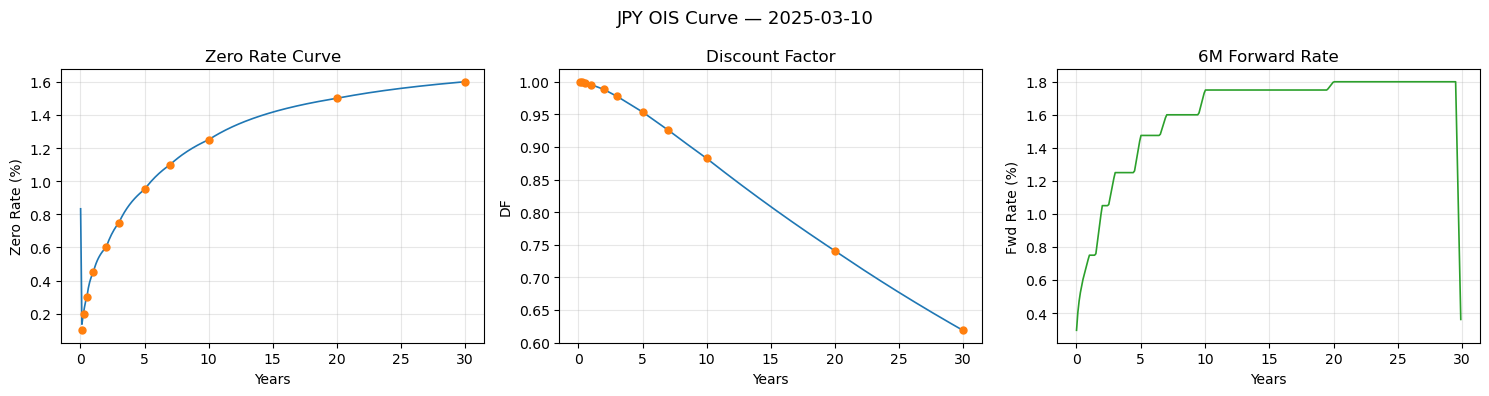

In [23]:
# ── 連続的に補間した zero rate / DF / forward rate を可視化 ──

t_grid = np.linspace(0.01, 30, 300)
z_grid = [ois.zero_rate(t) for t in t_grid]
df_grid = [ois.df(t) for t in t_grid]
fwd_grid = [ois.forward_rate(t, t + 0.5) for t in t_grid[:-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_grid, np.array(z_grid) * 100, "-", lw=1.2)
axes[0].plot(ois._t, ois._z * 100, "o", ms=5)
axes[0].set(xlabel="Years", ylabel="Zero Rate (%)", title="Zero Rate Curve")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_grid, df_grid, "-", lw=1.2)
axes[1].plot(ois._t, np.exp(ois._log_df), "o", ms=5)
axes[1].set(xlabel="Years", ylabel="DF", title="Discount Factor")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_grid[:-1], np.array(fwd_grid) * 100, "-", lw=1.2, color="C2")
axes[2].set(xlabel="Years", ylabel="Fwd Rate (%)", title="6M Forward Rate")
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"JPY OIS Curve — {ois.eval_date}", fontsize=13)
plt.tight_layout()
plt.show()

Bump: 5Y +10bp
  base  zero_rate(5Y) = 0.9500%
  bumped zero_rate(5Y) = 1.0500%
  diff = 10.00bp



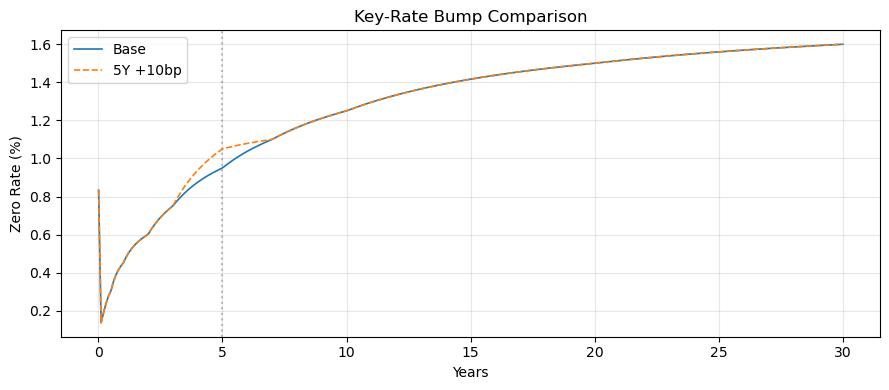

In [25]:
# ── key-rate bump テスト ───────────────────────────────
bump_tenor = "5Y"
bump_bp = 10.0  # +10bp

ois_bumped = ois.bump_key_rate(bump_tenor, bump_bp)

print(f"Bump: {bump_tenor} +{bump_bp:.0f}bp")
print(f"  base  zero_rate(5Y) = {ois.zero_rate(5.0)*100:.4f}%")
print(f"  bumped zero_rate(5Y) = {ois_bumped.zero_rate(5.0)*100:.4f}%")
print(f"  diff = {(ois_bumped.zero_rate(5.0) - ois.zero_rate(5.0))*10000:.2f}bp")
print()

# bump 前後の zero rate を比較プロット
fig, ax = plt.subplots(figsize=(9, 4))
z_base = [ois.zero_rate(t) * 100 for t in t_grid]
z_bump = [ois_bumped.zero_rate(t) * 100 for t in t_grid]
ax.plot(t_grid, z_base, "-", label="Base", lw=1.2)
ax.plot(t_grid, z_bump, "--", label=f"{bump_tenor} +{bump_bp:.0f}bp", lw=1.2)
ax.axvline(_tenor_to_years(bump_tenor), color="gray", ls=":", alpha=0.5)
ax.set(xlabel="Years", ylabel="Zero Rate (%)", title="Key-Rate Bump Comparison")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Fixed Bond Pricing — 動作確認

`price_fixed_riskfree` でサンプル JGB の PV を計算し、cashflow table と pricing summary を表示する。

In [33]:
result = price_fixed_riskfree(sample_bond, ois, sample_market.eval_date)

# ── Cashflow Table ────────────────────────────────────
print(f"Bond: {sample_bond.name}")
print(f"Settlement: {result.settlement_date}")
print(f"Remaining cashflows: {len(result.cashflow_df)}")
print()

# 表示用に金額列をフォーマット
display_cols = [
    "period_no", "accrual_start", "accrual_end", "payment_date",
    "pay_time_years", "accrual_factor", "is_fixed", "coupon_rate_used",
    "coupon_cashflow", "principal_cashflow", "total_cashflow",
    "discount_factor", "pv_contribution",
]
result.cashflow_df[display_cols]

Bond: JGB #368 (10Y 0.8%)
Settlement: 2025-03-12
Remaining cashflows: 19



,period_no,accrual_start,accrual_end,payment_date,pay_time_years,accrual_factor,is_fixed,coupon_rate_used,coupon_cashflow,principal_cashflow,total_cashflow,discount_factor,pv_contribution
0,2,2024-09-20,2025-03-20,2025-03-21,0.024658,0.495119,True,0.008,396095.516131,0.0,3.960955e+05,0.999917,3.960625e+05
1,3,2025-03-20,2025-09-20,2025-09-22,0.531507,0.504110,True,0.008,403287.671233,0.0,4.032877e+05,0.998312,4.026071e+05
2,4,2025-09-20,2026-03-20,2026-03-23,1.030137,0.495890,True,0.008,396712.328767,0.0,3.967123e+05,0.995285,3.948419e+05
3,5,2026-03-20,2026-09-20,2026-09-24,1.536986,0.504110,True,0.008,403287.671233,0.0,4.032877e+05,0.991509,3.998633e+05
4,6,2026-09-20,2027-03-20,2027-03-23,2.030137,0.495890,True,0.008,396712.328767,0.0,3.967123e+05,0.987759,3.918562e+05
5,7,2027-03-20,2027-09-20,2027-09-21,2.528767,0.504110,True,0.008,403287.671233,0.0,4.032877e+05,0.982601,3.962709e+05
6,8,2027-09-20,2028-03-20,2028-03-21,3.027397,0.498039,True,0.008,398431.020286,0.0,3.984310e+05,0.977416,3.894330e+05
7,9,2028-03-20,2028-09-20,2028-09-20,3.528767,0.502732,True,0.008,402185.792350,0.0,4.021858e+05,0.971310,3.906471e+05
8,10,2028-09-20,2029-03-20,2029-03-21,4.027397,0.495119,True,0.008,396095.516131,0.0,3.960955e+05,0.965275,3.823410e+05
9,11,2029-03-20,2029-09-20,2029-09-20,4.528767,0.504110,True,0.008,403287.671233,0.0,4.032877e+05,0.959244,3.868514e+05


In [34]:
# ── Pricing Summary ────────────────────────────────────
face = sample_bond.face_value

summary = pd.DataFrame([
    {"Item": "Face Value",        "JPY": f"{face:,.0f}",                       "per 100": "100.000000"},
    {"Item": "Dirty PV",          "JPY": f"{result.dirty_pv:,.0f}",            "per 100": f"{result.dirty_pv / face * 100:.6f}"},
    {"Item": "Accrued Interest",  "JPY": f"{result.accrued_interest:,.0f}",     "per 100": f"{result.accrued_interest / face * 100:.6f}"},
    {"Item": "Clean PV",          "JPY": f"{result.clean_pv:,.0f}",            "per 100": f"{result.clean_pv / face * 100:.6f}"},
])
print("=== Pricing Summary ===")
print(f"Eval date   : {sample_market.eval_date}")
print(f"Settlement  : {result.settlement_date}")
print(f"Coupon rate  : {sample_bond.coupon_rate*100:.3f}%")
print()
summary

=== Pricing Summary ===
Eval date   : 2025-03-10
Settlement  : 2025-03-12
Coupon rate  : 0.800%



,Item,JPY,per 100
0,Face Value,"100,000,000",100.000000
1,Dirty PV,"96,887,494",96.887494
2,Accrued Interest,"378,561",0.378561
3,Clean PV,"96,508,933",96.508933


In [35]:
# ── Sanity Checks ─────────────────────────────────────
checks_pv: list[tuple[str, bool, str]] = []

# 1) dirty = clean + accrued
recon = result.clean_pv + result.accrued_interest
checks_pv.append((
    "dirty = clean + accrued",
    abs(result.dirty_pv - recon) < 0.01,
    f"dirty={result.dirty_pv:,.2f}, clean+AI={recon:,.2f}, diff={result.dirty_pv - recon:,.4f}",
))

# 2) sum(pv_contribution) == dirty_pv
pv_sum = result.cashflow_df["pv_contribution"].sum()
checks_pv.append((
    "sum(pv_contribution) == dirty_pv",
    abs(pv_sum - result.dirty_pv) < 0.01,
    f"sum={pv_sum:,.2f}, dirty={result.dirty_pv:,.2f}",
))

# 3) accrued > 0 (settlement is between coupon dates)
checks_pv.append((
    "accrued > 0",
    result.accrued_interest > 0,
    f"AI={result.accrued_interest:,.2f}",
))

# 4) clean PV < dirty PV
checks_pv.append((
    "clean < dirty",
    result.clean_pv < result.dirty_pv,
    f"clean={result.clean_pv:,.2f}, dirty={result.dirty_pv:,.2f}",
))

# 5) last cashflow includes principal
last_row = result.cashflow_df.iloc[-1]
checks_pv.append((
    "last CF includes principal",
    last_row["principal_cashflow"] == sample_bond.face_value,
    f"principal_cf={last_row['principal_cashflow']:,.0f}, face={sample_bond.face_value:,.0f}",
))

for name, passed, detail in checks_pv:
    mark = "✅" if passed else "❌"
    print(f"  {mark} {name}: {detail}")

  ✅ dirty = clean + accrued: dirty=96,887,493.86, clean+AI=96,887,493.86, diff=0.0000
  ✅ sum(pv_contribution) == dirty_pv: sum=96,887,493.86, dirty=96,887,493.86
  ✅ accrued > 0: AI=378,561.27
  ✅ clean < dirty: clean=96,508,932.59, dirty=96,887,493.86
  ✅ last CF includes principal: principal_cf=100,000,000, face=100,000,000


## 8. OIS Key-Rate Delta / Gamma — 動作確認

`compute_ois_keyrate_delta_gamma` でサンプル JGB の key-rate リスクを計算する。

In [63]:
df_risk = compute_ois_keyrate_delta_gamma(sample_bond, ois, sample_market.eval_date)

total_delta = df_risk["delta_jpy_per_bp"].sum()
total_gamma = df_risk["gamma_jpy_per_bp2"].sum()

print(f"=== OIS Key-Rate Delta / Gamma ===")
print(f"Bond       : {sample_bond.name}")
print(f"Eval date  : {sample_market.eval_date}")
print(f"Base PV    : {df_risk['pv_base'].iloc[0]:,.2f} JPY")
print()
print(f"Total OIS Delta : {total_delta:,.2f} JPY/bp")
print(f"Total OIS Gamma : {total_gamma:,.4f} JPY/bp^2")
print()

# delta/gamma table
df_risk[["tenor", "delta_jpy_per_bp", "gamma_jpy_per_bp2"]]

=== OIS Key-Rate Delta / Gamma ===
Bond       : JGB #368 (10Y 0.8%)
Eval date  : 2025-03-10
Base PV    : 96,887,493.86 JPY

Total OIS Delta : -84,136.94 JPY/bp
Total OIS Gamma : 46.9126 JPY/bp^2



,tenor,delta_jpy_per_bp,gamma_jpy_per_bp2
0,1Y,-59.345448,0.004587
1,2Y,-158.680637,0.022890
2,3Y,-350.967196,0.073195
3,5Y,-761.842958,0.259418
4,7Y,-21531.214560,5.194972
5,10Y,-61274.886881,41.357581
6,20Y,0.000000,0.000000
7,30Y,0.000000,0.000000


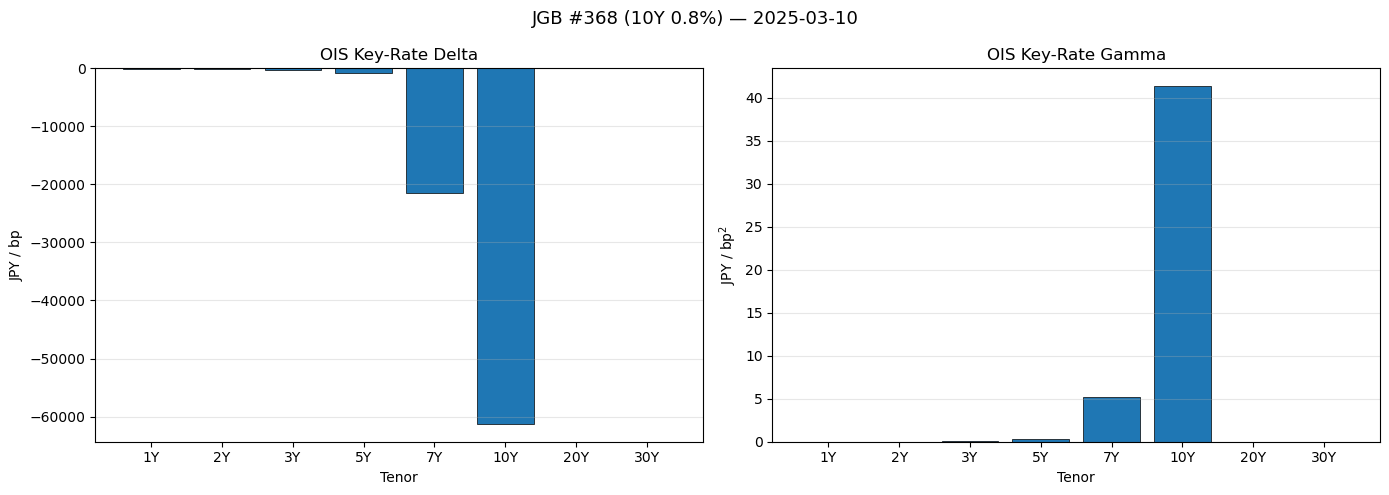

In [45]:
# ── OIS Bucket Delta Bar Chart ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta
colors_d = ["C0" if v < 0 else "C3" for v in df_risk["delta_jpy_per_bp"]]
axes[0].bar(df_risk["tenor"], df_risk["delta_jpy_per_bp"], color=colors_d, edgecolor="k", lw=0.5)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set(xlabel="Tenor", ylabel="JPY / bp", title="OIS Key-Rate Delta")
axes[0].grid(axis="y", alpha=0.3)

# Gamma
colors_g = ["C0" if v >= 0 else "C3" for v in df_risk["gamma_jpy_per_bp2"]]
axes[1].bar(df_risk["tenor"], df_risk["gamma_jpy_per_bp2"], color=colors_g, edgecolor="k", lw=0.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set(xlabel="Tenor", ylabel=r"JPY / bp$^2$", title="OIS Key-Rate Gamma")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle(f"{sample_bond.name} — {sample_market.eval_date}", fontsize=13)
plt.tight_layout()
plt.show()

In [47]:
# ── Sanity Checks ─────────────────────────────────────
checks_risk: list[tuple[str, bool, str]] = []

# 1) Total delta should be negative (bond loses value when rates rise)
checks_risk.append((
    "total delta < 0",
    total_delta < 0,
    f"total_delta={total_delta:,.2f}",
))

# 2) All gammas should be non-negative (convexity)
all_gamma_pos = (df_risk["gamma_jpy_per_bp2"] >= 0).all()
checks_risk.append((
    "all gamma >= 0",
    bool(all_gamma_pos),
    f"min_gamma={df_risk['gamma_jpy_per_bp2'].min():.4f}",
))

# 3) Delta concentrated around maturity tenor (10Y for a 10Y bond)
biggest_tenor = df_risk.loc[df_risk["delta_jpy_per_bp"].abs().idxmax(), "tenor"]
checks_risk.append((
    "largest delta bucket near maturity",
    biggest_tenor in ("7Y", "10Y"),
    f"largest bucket={biggest_tenor}",
))

# 4) For active tenors (delta != 0): pv_up < pv_base < pv_down
active = df_risk[df_risk["delta_jpy_per_bp"].abs() > 1e-6]
if len(active) > 0:
    up_down_ok = ((active["pv_up"] < active["pv_base"]) & (active["pv_base"] < active["pv_down"])).all()
else:
    up_down_ok = True
checks_risk.append((
    "pv_up < pv_base < pv_down (active tenors)",
    bool(up_down_ok),
    f"checked {len(active)} of {len(df_risk)} tenors",
))

# 5) 20Y/30Y delta ≒ 0 (bond matures at 10Y)
beyond_mat = df_risk[df_risk["tenor"].isin(["20Y", "30Y"])]
if len(beyond_mat) > 0:
    zero_beyond = (beyond_mat["delta_jpy_per_bp"].abs() < 1e-6).all()
else:
    zero_beyond = True
checks_risk.append((
    "delta ~ 0 for tenors beyond maturity",
    bool(zero_beyond),
    f"20Y={beyond_mat.iloc[0]['delta_jpy_per_bp']:.6f}, 30Y={beyond_mat.iloc[1]['delta_jpy_per_bp']:.6f}" if len(beyond_mat) == 2 else "N/A",
))

for name, passed, detail in checks_risk:
    mark = "✅" if passed else "❌"
    print(f"  {mark} {name}: {detail}")

  ✅ total delta < 0: total_delta=-84,136.94
  ✅ all gamma >= 0: min_gamma=0.0000
  ✅ largest delta bucket near maturity: largest bucket=10Y
  ✅ pv_up < pv_base < pv_down (active tenors): checked 6 of 8 tenors
  ✅ delta ~ 0 for tenors beyond maturity: 20Y=0.000000, 30Y=0.000000


### 6. Floating Rate Note (FRN) — Demo

TONA ベース FRN のサンプルデータを定義し、cashflow テーブルと pricing を確認する。

In [64]:
# ── FRN サンプルデータ ──────────────────────────────────
sample_frn = FloatingBondSpec(
    name="TONA FRN 5Y (spread +15bp)",
    spread=0.0015,                          # 15bp over TONA
    issue_date=dt.date(2024, 6, 20),
    maturity_date=dt.date(2029, 6, 20),
    face_value=100_000_000,
    coupon_frequency=4,                     # 四半期払い
    day_count="Actual365Fixed",
    calendar="Japan",
    settlement_days=2,
    fixing_lag=0,
)

# ── 確定 fixing (過去の利払い期間) ──────────────────────
# fixing_date → observed TONA compound rate for that period
sample_fixings: dict[dt.date, float] = {
    dt.date(2024, 6, 20): 0.0008,   # Q1: 2024/06/20 - 2024/09/20
    dt.date(2024, 9, 20): 0.0012,   # Q2: 2024/09/20 - 2024/12/20
    dt.date(2024, 12, 20): 0.0018,  # Q3: 2024/12/20 - 2025/03/20
}

print(f"FRN  : {sample_frn.name}")
print(f"Spread: {sample_frn.spread * 10_000:.0f} bp")
print(f"Eval : {sample_market.eval_date}")
print(f"Known fixings: {len(sample_fixings)} periods")

FRN  : TONA FRN 5Y (spread +15bp)
Spread: 15 bp
Eval : 2025-03-10
Known fixings: 3 periods


In [65]:
# ── FRN Pricing ──────────────────────────────────────
result_frn = price_float_riskfree(sample_frn, ois, sample_market.eval_date, sample_fixings)

print(f"Settlement : {result_frn.settlement_date}")
print(f"Dirty PV   : {result_frn.dirty_pv:>15,.0f} JPY")
print(f"Accrued Int: {result_frn.accrued_interest:>15,.0f} JPY")
print(f"Clean PV   : {result_frn.clean_pv:>15,.0f} JPY")
print(f"Face Value : {sample_frn.face_value:>15,.0f} JPY")
print()

# ── Cashflow Table ──
display_cols_frn = [
    "period_no", "accrual_start", "accrual_end", "payment_date", "fixing_date",
    "accrual_factor", "is_fixed", "forward_rate", "spread", "coupon_rate_used",
    "coupon_cashflow", "principal_cashflow", "discount_factor", "pv_contribution",
]
display(result_frn.cashflow_df[display_cols_frn])

Settlement : 2025-03-12
Dirty PV   :     100,700,610 JPY
Accrued Int:          74,137 JPY
Clean PV   :     100,626,473 JPY
Face Value :     100,000,000 JPY



,period_no,accrual_start,accrual_end,payment_date,fixing_date,accrual_factor,is_fixed,forward_rate,spread,coupon_rate_used,coupon_cashflow,principal_cashflow,discount_factor,pv_contribution
0,3,2024-12-20,2025-03-20,2025-03-21,2024-12-20,0.246575,True,0.001800,0.0015,0.003300,81369.863014,0.0,0.999917,8.136308e+04
1,4,2025-03-20,2025-06-20,2025-06-20,2025-03-20,0.252055,False,0.002034,0.0015,0.003534,89077.064923,0.0,0.999404,8.902400e+04
2,5,2025-06-20,2025-09-20,2025-09-22,2025-06-20,0.252055,False,0.004209,0.0015,0.005709,143891.845354,0.0,0.998312,1.436490e+05
3,6,2025-09-20,2025-12-20,2025-12-22,2025-09-20,0.249315,False,0.006004,0.0015,0.007504,187098.241586,0.0,0.996820,1.865033e+05
4,7,2025-12-20,2026-03-20,2026-03-23,2025-12-20,0.246575,False,0.006138,0.0015,0.007638,188333.592667,0.0,0.995285,1.874456e+05
5,8,2026-03-20,2026-06-20,2026-06-22,2026-03-20,0.252055,False,0.007507,0.0015,0.009007,227028.110396,0.0,0.993426,2.255356e+05
6,9,2026-06-20,2026-09-20,2026-09-24,2026-06-20,0.252055,False,0.007507,0.0015,0.009007,227028.110396,0.0,0.991509,2.251004e+05
7,10,2026-09-20,2026-12-20,2026-12-21,2026-09-20,0.249315,False,0.007507,0.0015,0.009007,224558.490042,0.0,0.989718,2.222495e+05
8,11,2026-12-20,2027-03-20,2027-03-23,2026-12-20,0.246575,False,0.007774,0.0015,0.009274,228676.642166,0.0,0.987759,2.258774e+05
9,12,2027-03-20,2027-06-20,2027-06-21,2027-03-20,0.252055,False,0.010514,0.0015,0.012014,302816.280641,0.0,0.985205,2.983361e+05


In [52]:
# ── FRN Sanity Checks ─────────────────────────────────
checks_frn: list[tuple[str, bool, str]] = []
cf_frn = result_frn.cashflow_df

# 1) 16 columns present
expected_cols = {
    "period_no", "accrual_start", "accrual_end", "payment_date", "fixing_date",
    "pay_time_years", "accrual_factor", "is_fixed", "coupon_rate_used",
    "forward_rate", "spread", "coupon_cashflow", "principal_cashflow",
    "total_cashflow", "discount_factor", "pv_contribution",
}
cols_ok = expected_cols.issubset(set(cf_frn.columns))
checks_frn.append(("16 columns present", cols_ok, f"got {len(cf_frn.columns)} cols"))

# 2) known vs projected separation
n_fixed = cf_frn["is_fixed"].sum()
n_proj = (~cf_frn["is_fixed"]).sum()
sep_ok = n_fixed >= 1 and n_proj >= 1
checks_frn.append((
    "known/projected fixing separation",
    sep_ok,
    f"fixed={n_fixed}, projected={n_proj}",
))

# 3) known fixings match input
fixed_rows = cf_frn[cf_frn["is_fixed"]]
all_match = all(
    abs(row["forward_rate"] - sample_fixings[row["fixing_date"]]) < 1e-12
    for _, row in fixed_rows.iterrows()
    if row["fixing_date"] in sample_fixings
)
checks_frn.append(("known fixing rates match input", all_match, ""))

# 4) last cashflow includes principal
last_cf = cf_frn.iloc[-1]
has_principal = abs(last_cf["principal_cashflow"] - sample_frn.face_value) < 1.0
checks_frn.append((
    "last CF includes face value redemption",
    has_principal,
    f"principal={last_cf['principal_cashflow']:,.0f}",
))

# 5) Near-par check: spread=0 FRN should price at ~face
frn_zero_spread = FloatingBondSpec(
    name="par-check FRN",
    spread=0.0,
    issue_date=sample_frn.issue_date,
    maturity_date=sample_frn.maturity_date,
    face_value=sample_frn.face_value,
    coupon_frequency=sample_frn.coupon_frequency,
    day_count=sample_frn.day_count,
    calendar=sample_frn.calendar,
    settlement_days=sample_frn.settlement_days,
    fixing_lag=sample_frn.fixing_lag,
)
res_par = price_float_riskfree(frn_zero_spread, ois, sample_market.eval_date)
pv_ratio = res_par.dirty_pv / sample_frn.face_value
near_par = abs(pv_ratio - 1.0) < 0.005  # 0.5% tolerance
checks_frn.append((
    "spread=0 FRN dirty PV ≈ face (par check)",
    near_par,
    f"PV/Face = {pv_ratio:.6f}",
))

# 6) spread impact: positive spread → dirty PV > face
spread_premium = result_frn.dirty_pv > sample_frn.face_value * 0.999
checks_frn.append((
    "positive spread → PV ≈ or > face",
    spread_premium,
    f"dirty PV = {result_frn.dirty_pv:,.0f}",
))

print("FRN Sanity Checks:")
for name, passed, detail in checks_frn:
    mark = "✅" if passed else "❌"
    suffix = f" — {detail}" if detail else ""
    print(f"  {mark} {name}{suffix}")

FRN Sanity Checks:
  ✅ 16 columns present — got 16 cols
  ✅ known/projected fixing separation — fixed=1, projected=17
  ✅ known fixing rates match input
  ✅ last CF includes face value redemption — principal=100,000,000
  ✅ spread=0 FRN dirty PV ≈ face (par check) — PV/Face = 1.000853
  ✅ positive spread → PV ≈ or > face — dirty PV = 100,700,610


### 7. FRN OIS Key-Rate Delta / Gamma — Fixed vs FRN 比較

FRN の OIS key-rate delta/gamma を計算し、固定利付債と並べて risk profile の違いを確認する。

**ポイント**: single-curve approach なので、OIS bump は **forward projection** (coupon の参照レート) と
**discounting** (PV 計算の割引) の両方に同時に効く。spread=0 の FRN は bump に対して
「forward rate ↑ → coupon ↑」と「discount ↑ → PV ↓」がほぼ相殺するため、
固定利付債よりも delta が大幅に小さくなる。

In [66]:
# ── FRN Key-Rate Delta / Gamma ────────────────────────
df_risk_frn = compute_ois_keyrate_delta_gamma_frn(
    sample_frn, ois, sample_market.eval_date, sample_fixings,
)

total_delta_frn = df_risk_frn["delta_jpy_per_bp"].sum()
total_gamma_frn = df_risk_frn["gamma_jpy_per_bp2"].sum()

print(f"=== FRN OIS Key-Rate Delta / Gamma ===")
print(f"FRN        : {sample_frn.name}")
print(f"Eval date  : {sample_market.eval_date}")
print(f"Base PV    : {df_risk_frn['pv_base'].iloc[0]:,.2f} JPY")
print()
print(f"Total OIS Delta : {total_delta_frn:,.2f} JPY/bp")
print(f"Total OIS Gamma : {total_gamma_frn:,.4f} JPY/bp^2")
print()

df_risk_frn[["tenor", "delta_jpy_per_bp", "gamma_jpy_per_bp2"]]

=== FRN OIS Key-Rate Delta / Gamma ===
FRN        : TONA FRN 5Y (spread +15bp)
Eval date  : 2025-03-10
Base PV    : 100,700,609.90 JPY

Total OIS Delta : -141.00 JPY/bp
Total OIS Gamma : -0.0603 JPY/bp^2



,tenor,delta_jpy_per_bp,gamma_jpy_per_bp2
0,1Y,-10.850906,-0.013922
1,2Y,-30.747254,-0.033416
2,3Y,-63.312584,-0.012361
3,5Y,-36.084824,-0.000554
4,7Y,0.000000,0.000000
5,10Y,0.000000,0.000000
6,20Y,0.000000,0.000000
7,30Y,0.000000,0.000000


In [69]:
# ── Fixed vs FRN 比較テーブル ──────────────────────────
# テナー順序を定義してソート
tenor_order = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]

df_cmp = pd.merge(
    df_risk[["tenor", "delta_jpy_per_bp", "gamma_jpy_per_bp2"]].rename(
        columns={"delta_jpy_per_bp": "fixed_delta", "gamma_jpy_per_bp2": "fixed_gamma"}
    ),
    df_risk_frn[["tenor", "delta_jpy_per_bp", "gamma_jpy_per_bp2"]].rename(
        columns={"delta_jpy_per_bp": "frn_delta", "gamma_jpy_per_bp2": "frn_gamma"}
    ),
    on="tenor",
    how="outer",
).fillna(0.0)

# テナー順でソート
df_cmp["_sort"] = df_cmp["tenor"].map({t: i for i, t in enumerate(tenor_order)})
df_cmp = df_cmp.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)

# delta ratio (FRN / Fixed) — fixed の delta が 0 に近い場合は N/A
df_cmp["delta_ratio"] = df_cmp.apply(
    lambda r: r["frn_delta"] / r["fixed_delta"] if abs(r["fixed_delta"]) > 1e-6 else float("nan"),
    axis=1,
)

print("=== Fixed Bond vs FRN — Key-Rate Delta Comparison ===")
print(f"Fixed : {sample_bond.name}")
print(f"FRN   : {sample_frn.name}")
print(f"Eval  : {sample_market.eval_date}")
print()
print(f"{'':>6}  {'Fixed Delta':>14}  {'FRN Delta':>14}  {'Ratio':>8}")
print(f"{'':>6}  {'(JPY/bp)':>14}  {'(JPY/bp)':>14}  {'FRN/Fix':>8}")
print("-" * 52)
for _, row in df_cmp.iterrows():
    ratio_str = f"{row['delta_ratio']:.4f}" if not np.isnan(row['delta_ratio']) else "N/A"
    print(f"{row['tenor']:>6}  {row['fixed_delta']:>14,.2f}  {row['frn_delta']:>14,.2f}  {ratio_str:>8}")
print("-" * 52)
print(f"{'Total':>6}  {df_cmp['fixed_delta'].sum():>14,.2f}  {df_cmp['frn_delta'].sum():>14,.2f}")
print()

display(df_cmp)

=== Fixed Bond vs FRN — Key-Rate Delta Comparison ===
Fixed : JGB #368 (10Y 0.8%)
FRN   : TONA FRN 5Y (spread +15bp)
Eval  : 2025-03-10

           Fixed Delta       FRN Delta     Ratio
              (JPY/bp)        (JPY/bp)   FRN/Fix
----------------------------------------------------
    1Y          -59.35          -10.85    0.1828
    2Y         -158.68          -30.75    0.1938
    3Y         -350.97          -63.31    0.1804
    5Y         -761.84          -36.08    0.0474
    7Y      -21,531.21            0.00   -0.0000
   10Y      -61,274.89            0.00   -0.0000
   20Y            0.00            0.00       N/A
   30Y            0.00            0.00       N/A
----------------------------------------------------
 Total      -84,136.94         -141.00



,tenor,fixed_delta,fixed_gamma,frn_delta,frn_gamma,delta_ratio
0,1Y,-59.345448,0.004587,-10.850906,-0.013922,0.182843
1,2Y,-158.680637,0.022890,-30.747254,-0.033416,0.193768
2,3Y,-350.967196,0.073195,-63.312584,-0.012361,0.180395
3,5Y,-761.842958,0.259418,-36.084824,-0.000554,0.047365
4,7Y,-21531.214560,5.194972,0.000000,0.000000,-0.000000
5,10Y,-61274.886881,41.357581,0.000000,0.000000,-0.000000
6,20Y,0.000000,0.000000,0.000000,0.000000,NaN
7,30Y,0.000000,0.000000,0.000000,0.000000,NaN


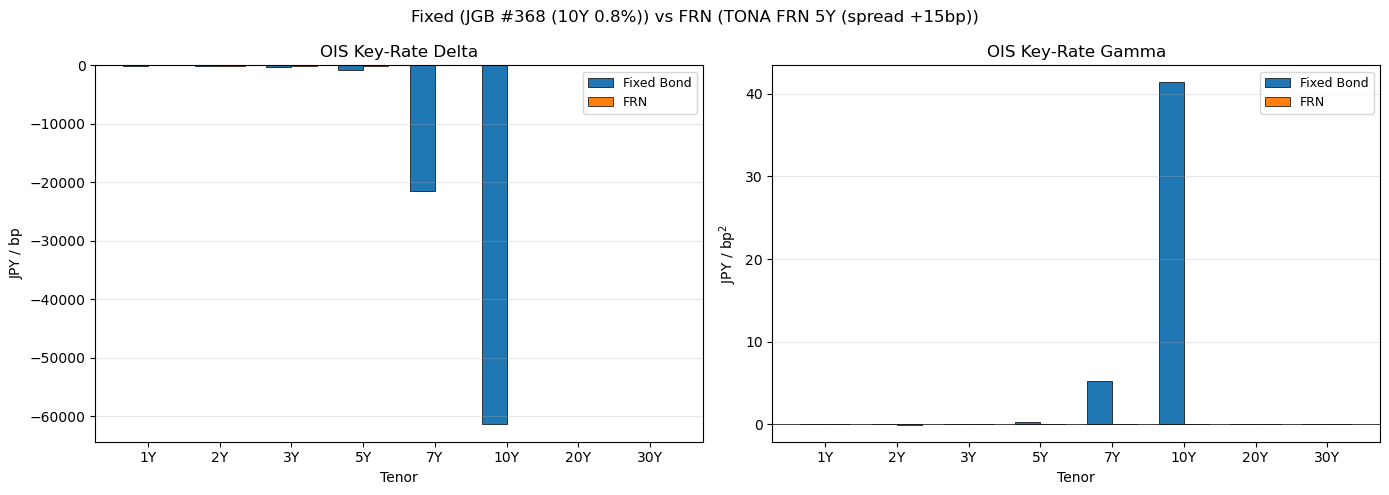

In [70]:
# ── Fixed vs FRN Delta / Gamma 比較チャート ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df_cmp))
w = 0.35

# Delta comparison
axes[0].bar(x - w/2, df_cmp["fixed_delta"], w, label="Fixed Bond", color="C0", edgecolor="k", lw=0.5)
axes[0].bar(x + w/2, df_cmp["frn_delta"], w, label="FRN", color="C1", edgecolor="k", lw=0.5)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_cmp["tenor"])
axes[0].set(xlabel="Tenor", ylabel="JPY / bp", title="OIS Key-Rate Delta")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Gamma comparison
axes[1].bar(x - w/2, df_cmp["fixed_gamma"], w, label="Fixed Bond", color="C0", edgecolor="k", lw=0.5)
axes[1].bar(x + w/2, df_cmp["frn_gamma"], w, label="FRN", color="C1", edgecolor="k", lw=0.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_cmp["tenor"])
axes[1].set(xlabel="Tenor", ylabel=r"JPY / bp$^2$", title="OIS Key-Rate Gamma")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle(f"Fixed ({sample_bond.name}) vs FRN ({sample_frn.name})", fontsize=12)
plt.tight_layout()
plt.show()

In [71]:
# ── FRN Risk Sanity Checks ─────────────────────────────
checks_frn_risk: list[tuple[str, bool, str]] = []

# 1) FRN total |delta| << Fixed total |delta|
#    FRN はフォワードレート変動がクーポンに反映されるため金利感応度が大幅に低い
abs_fixed = abs(df_cmp["fixed_delta"].sum())
abs_frn = abs(df_cmp["frn_delta"].sum())
much_smaller = abs_frn < abs_fixed * 0.3  # FRN delta が Fixed の 30% 未満
checks_frn_risk.append((
    "FRN |total delta| << Fixed |total delta|",
    much_smaller,
    f"|Fixed|={abs_fixed:,.0f}, |FRN|={abs_frn:,.0f}, ratio={abs_frn/abs_fixed:.4f}" if abs_fixed > 0 else "N/A",
))

# 2) FRN delta は短期バケットに集中 (longest active tenor <= maturity の前半)
frn_active = df_risk_frn[df_risk_frn["delta_jpy_per_bp"].abs() > 1e-2]
if len(frn_active) > 0:
    largest_frn_bucket = frn_active.loc[frn_active["delta_jpy_per_bp"].abs().idxmax(), "tenor"]
    # FRN 5Y → delta が最も大きいのは短期～中期バケットのはず
    short_mid = largest_frn_bucket in ("1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y")
else:
    largest_frn_bucket = "N/A"
    short_mid = True
checks_frn_risk.append((
    "FRN largest delta bucket in short/mid tenors",
    short_mid,
    f"largest={largest_frn_bucket}",
))

# 3) Fixed delta は maturity 近辺に集中 (10Y bond → 7Y or 10Y bucket)
fixed_active = df_risk[df_risk["delta_jpy_per_bp"].abs() > 1e-2]
if len(fixed_active) > 0:
    largest_fixed_bucket = fixed_active.loc[fixed_active["delta_jpy_per_bp"].abs().idxmax(), "tenor"]
    near_mat = largest_fixed_bucket in ("7Y", "10Y")
else:
    largest_fixed_bucket = "N/A"
    near_mat = True
checks_frn_risk.append((
    "Fixed largest delta bucket near maturity",
    near_mat,
    f"largest={largest_fixed_bucket}",
))

# 4) FRN gamma は Fixed gamma より小さい
frn_gamma_total = abs(df_cmp["frn_gamma"].sum())
fixed_gamma_total = abs(df_cmp["fixed_gamma"].sum())
gamma_smaller = frn_gamma_total < fixed_gamma_total
checks_frn_risk.append((
    "FRN total |gamma| < Fixed total |gamma|",
    gamma_smaller,
    f"|Fixed|={fixed_gamma_total:,.4f}, |FRN|={frn_gamma_total:,.4f}",
))

# 5) maturity 超のテナーでは FRN delta ≈ 0
frn_beyond = df_risk_frn[df_risk_frn["tenor"].isin(["7Y", "10Y", "20Y", "30Y"])]
years_frn = (sample_frn.maturity_date - sample_market.eval_date).days / 365.25
frn_past_mat = frn_beyond[frn_beyond["tenor"].apply(lambda t: _tenor_to_years(t) > years_frn + 0.5)]
if len(frn_past_mat) > 0:
    frn_zero_beyond = (frn_past_mat["delta_jpy_per_bp"].abs() < 1e-4).all()
else:
    frn_zero_beyond = True
checks_frn_risk.append((
    "FRN delta ≈ 0 for tenors beyond maturity",
    bool(frn_zero_beyond),
    f"checked {len(frn_past_mat)} tenors beyond {years_frn:.1f}Y",
))

print("FRN Risk Sanity Checks:")
for name, passed, detail in checks_frn_risk:
    mark = "✅" if passed else "❌"
    print(f"  {mark} {name}: {detail}")
print()

# ── Commentary ────────────────────────────────────────
print("=" * 60)
print("Risk Profile 比較コメント")
print("=" * 60)
print(f"""
1. 金利感応度の大きさ:
   Fixed Bond total delta = {df_cmp['fixed_delta'].sum():,.0f} JPY/bp
   FRN          total delta = {df_cmp['frn_delta'].sum():,.0f} JPY/bp
   → FRN の delta は Fixed の {abs_frn/abs_fixed*100:.1f}% 程度。
     FRN はクーポンが市場金利に連動するため duration が短い。

2. Delta のバケット分布:
   Fixed: maturity 近辺 ({largest_fixed_bucket}) に集中 — bullet bond の典型。
   FRN  : 直近の fixing 期間 ({largest_frn_bucket}) に集中 — 次回リセットまでの
          短期的な感応度のみ。

3. Gamma (convexity):
   Fixed gamma = {fixed_gamma_total:,.4f} JPY/bp²
   FRN   gamma = {frn_gamma_total:,.4f} JPY/bp²
   → FRN は convexity もほぼゼロ。

4. 結論:
   FRN は金利リスクヘッジとして有効 — 同じ残存の Fixed Bond と比べ
   OIS delta が 1 桁以上小さい。ただしスプレッドリスク (CS01) は残る。
""")

FRN Risk Sanity Checks:
  ✅ FRN |total delta| << Fixed |total delta|: |Fixed|=84,137, |FRN|=141, ratio=0.0017
  ✅ FRN largest delta bucket in short/mid tenors: largest=3Y
  ✅ Fixed largest delta bucket near maturity: largest=10Y
  ✅ FRN total |gamma| < Fixed total |gamma|: |Fixed|=46.9126, |FRN|=0.0603
  ✅ FRN delta ≈ 0 for tenors beyond maturity: checked 4 tenors beyond 4.3Y

Risk Profile 比較コメント

1. 金利感応度の大きさ:
   Fixed Bond total delta = -84,137 JPY/bp
   FRN          total delta = -141 JPY/bp
   → FRN の delta は Fixed の 0.2% 程度。
     FRN はクーポンが市場金利に連動するため duration が短い。

2. Delta のバケット分布:
   Fixed: maturity 近辺 (10Y) に集中 — bullet bond の典型。
   FRN  : 直近の fixing 期間 (3Y) に集中 — 次回リセットまでの
          短期的な感応度のみ。

3. Gamma (convexity):
   Fixed gamma = 46.9126 JPY/bp²
   FRN   gamma = 0.0603 JPY/bp²
   → FRN は convexity もほぼゼロ。

4. 結論:
   FRN は金利リスクヘッジとして有効 — 同じ残存の Fixed Bond と比べ
   OIS delta が 1 桁以上小さい。ただしスプレッドリスク (CS01) は残る。



### 8. Fixed Bond + Z-Spread — Pricing & Risk Demo

JGB #368 に z-spread = 50bp を上乗せして pricing し、
OIS delta/gamma と z-spread delta/gamma を分離して表示する。

In [73]:
# ── Z-Spread Pricing ──────────────────────────────────
sample_credit = CreditSpread(z_spread=0.0050)  # 50bp

result_zs = price_fixed_zspread(sample_bond, ois, sample_credit, sample_market.eval_date)

print(f"=== Fixed Bond + Z-Spread Pricing ===")
print(f"Bond       : {sample_bond.name}")
print(f"Z-Spread   : {sample_credit}")
print(f"Eval date  : {sample_market.eval_date}")
print(f"Settlement : {result_zs.settlement_date}")
print()
print(f"Dirty PV   : {result_zs.dirty_pv:>15,.0f} JPY")
print(f"Accrued Int: {result_zs.accrued_interest:>15,.0f} JPY")
print(f"Clean PV   : {result_zs.clean_pv:>15,.0f} JPY")
print()
print(f"[参考] Risk-Free Dirty PV : {result.dirty_pv:>15,.0f} JPY")
print(f"       PV差 (credit cost) : {result_zs.dirty_pv - result.dirty_pv:>15,.0f} JPY")
print()

# Cashflow 比較: df_ois vs df_total
display(result_zs.cashflow_df[[
    "period_no", "payment_date", "pay_time_years", "total_cashflow",
    "df_ois", "survival_df", "df_total", "pv_contribution",
]])

=== Fixed Bond + Z-Spread Pricing ===
Bond       : JGB #368 (10Y 0.8%)
Z-Spread   : CreditSpread(z=50.0bp)
Eval date  : 2025-03-10
Settlement : 2025-03-12

Dirty PV   :      92,772,089 JPY
Accrued Int:         378,561 JPY
Clean PV   :      92,393,528 JPY

[参考] Risk-Free Dirty PV :      96,887,494 JPY
       PV差 (credit cost) :      -4,115,405 JPY



,period_no,payment_date,pay_time_years,total_cashflow,df_ois,survival_df,df_total,pv_contribution
0,2,2025-03-21,0.024658,3.960955e+05,0.999917,0.999877,0.999793,3.960137e+05
1,3,2025-09-22,0.531507,4.032877e+05,0.998312,0.997346,0.995663,4.015386e+05
2,4,2026-03-23,1.030137,3.967123e+05,0.995285,0.994863,0.990172,3.928134e+05
3,5,2026-09-24,1.536986,4.032877e+05,0.991509,0.992345,0.983918,3.968022e+05
4,6,2027-03-23,2.030137,3.967123e+05,0.987759,0.989901,0.977783,3.878987e+05
5,7,2027-09-21,2.528767,4.032877e+05,0.982601,0.987436,0.970255,3.912921e+05
6,8,2028-03-21,3.027397,3.984310e+05,0.977416,0.984977,0.962733,3.835826e+05
7,9,2028-09-20,3.528767,4.021858e+05,0.971310,0.982511,0.954323,3.838150e+05
8,10,2029-03-21,4.027397,3.960955e+05,0.965275,0.980064,0.946031,3.747188e+05
9,11,2029-09-20,4.528767,4.032877e+05,0.959244,0.977611,0.937767,3.781900e+05


In [74]:
# ── OIS Delta/Gamma (z-spread 固定) ───────────────────
df_ois_risk_zs = compute_ois_delta_gamma_with_zspread(
    sample_bond, ois, sample_credit, sample_market.eval_date,
)
ois_total_delta_zs = df_ois_risk_zs["delta_jpy_per_bp"].sum()
ois_total_gamma_zs = df_ois_risk_zs["gamma_jpy_per_bp2"].sum()

# ── Z-Spread Delta/Gamma (OIS 固定) ──────────────────
zs_risk = compute_zspread_delta_gamma(
    sample_bond, ois, sample_credit, sample_market.eval_date,
)
zs_delta = zs_risk["zspread_delta_jpy_per_bp"]
zs_gamma = zs_risk["zspread_gamma_jpy_per_bp2"]

# ── Summary ──────────────────────────────────────────
print("=" * 60)
print("Fixed Bond + Z-Spread — Risk Summary")
print("=" * 60)
print(f"Bond      : {sample_bond.name}")
print(f"Z-Spread  : {sample_credit.z_spread * 10_000:.0f} bp")
print(f"Base PV   : {zs_risk['pv_base']:,.0f} JPY")
print()

summary_zs = pd.DataFrame({
    "risk_type": ["OIS Key-Rate (total)", "Z-Spread (parallel)"],
    "delta_jpy_per_bp": [ois_total_delta_zs, zs_delta],
    "gamma_jpy_per_bp2": [ois_total_gamma_zs, zs_gamma],
})
display(summary_zs)

print()
print("OIS Key-Rate Delta Breakdown:")
display(df_ois_risk_zs[["tenor", "delta_jpy_per_bp", "gamma_jpy_per_bp2"]])

print()
print("Z-Spread Delta Detail:")
print(f"  PV(z+1bp) = {zs_risk['pv_up']:>15,.2f}")
print(f"  PV(z-1bp) = {zs_risk['pv_down']:>15,.2f}")
print(f"  PV(base)  = {zs_risk['pv_base']:>15,.2f}")
print(f"  Delta     = {zs_delta:>15,.2f} JPY/bp")
print(f"  Gamma     = {zs_gamma:>15,.4f} JPY/bp²")

Fixed Bond + Z-Spread — Risk Summary
Bond      : JGB #368 (10Y 0.8%)
Z-Spread  : 50 bp
Base PV   : 92,772,089 JPY



,risk_type,delta_jpy_per_bp,gamma_jpy_per_bp2
0,OIS Key-Rate (total),-80467.074244,44.855442
1,Z-Spread (parallel),-80486.868565,71.763940



OIS Key-Rate Delta Breakdown:


,tenor,delta_jpy_per_bp,gamma_jpy_per_bp2
0,1Y,-59.000245,0.004562
1,2Y,-157.102769,0.022662
2,3Y,-345.178562,0.072019
3,5Y,-743.072225,0.253019
4,7Y,-20591.358261,4.970879
5,10Y,-58571.362182,39.532303
6,20Y,0.000000,0.000000
7,30Y,0.000000,0.000000



Z-Spread Delta Detail:
  PV(z+1bp) =   92,691,638.24
  PV(z-1bp) =   92,852,611.97
  PV(base)  =   92,772,089.22
  Delta     =      -80,486.87 JPY/bp
  Gamma     =         71.7639 JPY/bp²


In [75]:
# ── Z-Spread Sanity Checks ────────────────────────────
checks_zs: list[tuple[str, bool, str]] = []

# 1) z-spread > 0 → PV(z-spread) < PV(risk-free)
pv_rf = result.dirty_pv
pv_zs = result_zs.dirty_pv
zs_reduces_pv = pv_zs < pv_rf
checks_zs.append((
    "z-spread > 0 → PV < risk-free PV",
    zs_reduces_pv,
    f"RF={pv_rf:,.0f}, ZS={pv_zs:,.0f}, diff={pv_zs - pv_rf:,.0f}",
))

# 2) z-spread bump up → PV down (negative delta)
zs_delta_neg = zs_delta < 0
checks_zs.append((
    "z-spread delta < 0 (spread↑ → PV↓)",
    zs_delta_neg,
    f"delta={zs_delta:,.2f} JPY/bp",
))

# 3) z-spread gamma > 0 (convexity)
zs_gamma_pos = zs_gamma > 0
checks_zs.append((
    "z-spread gamma > 0 (convexity)",
    zs_gamma_pos,
    f"gamma={zs_gamma:,.4f} JPY/bp²",
))

# 4) PV(z+1bp) < PV(base) < PV(z-1bp)
pv_ordering = zs_risk["pv_up"] < zs_risk["pv_base"] < zs_risk["pv_down"]
checks_zs.append((
    "PV(z+1bp) < PV(base) < PV(z-1bp)",
    pv_ordering,
    f"up={zs_risk['pv_up']:,.0f}, base={zs_risk['pv_base']:,.0f}, down={zs_risk['pv_down']:,.0f}",
))

# 5) z-spread=0 → PV = risk-free PV
credit_zero = CreditSpread(z_spread=0.0)
pv_zero_zs = price_fixed_zspread(sample_bond, ois, credit_zero, sample_market.eval_date).dirty_pv
diff_zero = abs(pv_zero_zs - pv_rf)
checks_zs.append((
    "z-spread=0 → PV = risk-free PV",
    diff_zero < 1.0,
    f"diff={diff_zero:.6f}",
))

# 6) OIS delta (with z-spread) ≈ OIS delta (risk-free) — same sign, similar magnitude
ois_delta_rf = df_risk["delta_jpy_per_bp"].sum()
ois_delta_zs = ois_total_delta_zs
ratio_ois = ois_delta_zs / ois_delta_rf if abs(ois_delta_rf) > 1e-6 else float("nan")
# z-spread reduces DF → smaller PV → slightly smaller delta magnitude
similar_ois = 0.8 < ratio_ois < 1.2
checks_zs.append((
    "OIS delta (w/ z-spread) ≈ OIS delta (risk-free)",
    similar_ois,
    f"ratio={ratio_ois:.4f} (RF={ois_delta_rf:,.0f}, ZS={ois_delta_zs:,.0f})",
))

# 7) |z-spread delta| ≈ |OIS total delta| (similar duration effect)
ratio_cs01 = abs(zs_delta) / abs(ois_total_delta_zs) if abs(ois_total_delta_zs) > 1e-6 else float("nan")
cs01_similar = 0.5 < ratio_cs01 < 2.0
checks_zs.append((
    "|z-spread delta| same order as |OIS total delta|",
    cs01_similar,
    f"|CS01|={abs(zs_delta):,.0f}, |OIS Δ|={abs(ois_total_delta_zs):,.0f}, ratio={ratio_cs01:.4f}",
))

print("Z-Spread Sanity Checks:")
for name, passed, detail in checks_zs:
    mark = "✅" if passed else "❌"
    print(f"  {mark} {name}: {detail}")

Z-Spread Sanity Checks:
  ✅ z-spread > 0 → PV < risk-free PV: RF=96,887,494, ZS=92,772,089, diff=-4,115,405
  ✅ z-spread delta < 0 (spread↑ → PV↓): delta=-80,486.87 JPY/bp
  ✅ z-spread gamma > 0 (convexity): gamma=71.7639 JPY/bp²
  ✅ PV(z+1bp) < PV(base) < PV(z-1bp): up=92,691,638, base=92,772,089, down=92,852,612
  ✅ z-spread=0 → PV = risk-free PV: diff=0.000000
  ✅ OIS delta (w/ z-spread) ≈ OIS delta (risk-free): ratio=0.9564 (RF=-84,137, ZS=-80,467)
  ✅ |z-spread delta| same order as |OIS total delta|: |CS01|=80,487, |OIS Δ|=80,467, ratio=1.0002


## Next Steps

- [ ] PnL Attribution: Carry / Roll-down / Rate Δ / Residual 分解
- [ ] 複数銘柄ポートフォリオ対応

### 完了済み
- [x] データ構造定義 (`BondSpec` / `MarketSnapshot` / `RiskConfig` / `FloatingBondSpec`)
- [x] Date / Schedule ユーティリティ (`build_coupon_schedule_df`, `get_settlement_date`, `compute_accrual_factor`)
- [x] OIS Curve クラス (`OISCurve`: df, zero_rate, forward_rate, bump_key_rate)
- [x] Fixed Bond Pricing (`price_fixed_riskfree`: dirty PV, accrued interest, clean PV)
- [x] OIS Key-Rate Delta / Gamma — Fixed Bond (`compute_ois_keyrate_delta_gamma`)
- [x] Floating Rate Note Pricing (`price_float_riskfree`: simply compounded forwards, known/projected fixing separation)
- [x] OIS Key-Rate Delta / Gamma — FRN (`compute_ois_keyrate_delta_gamma_frn`, Fixed vs FRN 比較)
- [x] Fixed Bond + Z-Spread (`CreditSpread`, `price_fixed_zspread`, `compute_zspread_delta_gamma`, OIS/credit risk 分離)